# Experiment: 2D cond 1D

dim(x)=1, dim(y)=1 — comparing LGD vs LGD-CM.

In [1]:
import os

REPO_URL = "https://github.com/orineo1/conditional-matching-paper.git"
REPO_DIR = "/content/conditional-matching-paper"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}/simulations
!pip install -q -r requirements.txt

import sys
sys.path.insert(0, f"{REPO_DIR}/simulations/src")

Cloning into '/content/conditional-matching-paper'...
remote: Enumerating objects: 11794, done.
remote: Counting objects: 100% (265/265), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 11794 (delta 230), reused 223 (delta 212), pack-reused 11529 (from 2)
Receiving objects: 100% (11794/11794), 1.21 GiB | 39.43 MiB/s, done.
Resolving deltas: 100% (5340/5340), done.
/content/conditional-matching-paper/simulations
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 125.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 59.1 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
import os
# ============================================================
# CONFIG — only this cell changes between notebooks
# Structure:
#   simulations/src/        ← all .py modules
#   simulations/notebooks/  ← this notebook
#   simulations/params/     ← canonical GMM parameters (shared, load first)
#   simulations/checkpoints/
#   simulations/results/
# ============================================================
EXPERIMENT_NAME   = "2D_cond_1D"
GLOBAL_SEED       = 42
FORCE_RETRAIN     = True

BASE_DIR = os.path.normpath(os.path.join(os.getcwd(), ".."))
PARAMS_DIR        = f"{BASE_DIR}/params"
CHECKPOINT_DIR    = f"{BASE_DIR}/checkpoints/{EXPERIMENT_NAME}"
RESULTS_DIR       = f"{BASE_DIR}/results/{EXPERIMENT_NAME}"

# Architecture — Diffusion models
NBLOCKS           = 3
NUNITS            = 128

# Architecture — Consistency Model (separate so it can be scaled independently)
NBLOCKS_CM        = 3
NUNITS_CM         = 128

# Training — Diffusion
NEPOCHS           = 3_000
BATCH_SIZE        = 1_024

# Training — Consistency Model
NEPOCHS_CM        = 3_000
BATCH_SIZE_CM     = 1_024

# Diffusion
DIFFUSION_STEPS   = 100

# Optimization
N_ATTEMP_OPTIM              = 1
NSAMPLES_IN_OPTIM_FOR_MMD   = 250
NUM_X_T_LGD                 = 1
NUM_X_T_LGD_CM              = 1

# GMM dimensions
CONDITION_ON      = 1   # dim(x)=1, dim(y)=1

In [3]:
import os, sys

# ── point Python at simulations/src where all .py modules live ──
src_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "src")
src_path = os.path.normpath(src_path)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"src path on sys.path: {src_path}")

src path on sys.path: /content/conditional-matching-paper/src


In [4]:
# Install dependencies if needed
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "flow_matching", "POT", "-q"])

0

In [5]:
import os, sys, time, json
import importlib
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange

import Diffusion
import LossFunctions
import ConsistencyModels
import dist_utils
import Optimization
import experiment_utils
from ConsistencyModels import ConsistencyModeliCT
from LossFunctions import MMDLoss, RBF

for mod in [Diffusion, LossFunctions, ConsistencyModels,
            dist_utils, Optimization, experiment_utils]:
    importlib.reload(mod)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,    exist_ok=True)
os.makedirs(PARAMS_DIR,     exist_ok=True)
print("Imports done.")

Imports done.


In [6]:
env_info = experiment_utils.get_environment_info()
experiment_utils.print_environment_info(env_info)

/content/conditional-matching-paper/simulations/src/experiment_utils.py:47: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ENVIRONMENT INFO
  timestamp: 2026-09-22T06:37:28.690928
  torch_version: 2.11.0+cu128
  cuda_available: True
  cuda_version: 12.8
  device_name: Tesla T4
  packages: {'torch': '2.11.0+cu128', 'numpy': '2.1.3', 'flow_matching': '1.0.10', 'POT': '0.9.7.post1', 'matplotlib': '3.10.0', 'pandas': '2.2.3', 'tqdm': '4.67.3'}
  packages:


In [7]:
experiment_utils.set_global_seed(GLOBAL_SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

[Seed] All random seeds set to 42
Using device: cuda


## GMM Parameters

/content/conditional-matching-paper/simulations/src/dist_utils.py:356: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  exponent = -0.5 * diff.T @ Sigma_22_inv @ diff


x_star = [-3.0]
Conditional modes after filtering: 1
[Seed] All random seeds set to 42


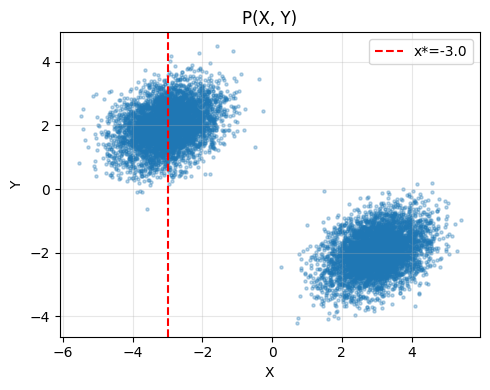

In [8]:
mu_list = [
    torch.tensor([-3.,  2.]),
    torch.tensor([ 3., -2.]),
]
Sigma_list = [
    torch.tensor([[0.5, 0.15],
                  [0.15, 0.4]]),
    torch.tensor([[0.5, 0.15],
                  [0.15, 0.4]]),
]
alpha  = torch.tensor([0.5, 0.5])
x_star = torch.tensor([-3.])

# Target G = P(Y | X = x_star)
mu_temp, Sigma_temp = dist_utils.compute_conditionals(mu_list, Sigma_list, x_star)
w_temp              = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star)
mog_means, mog_variances, weights = dist_utils.filter_and_normalize(
    mu_temp, Sigma_temp, w_temp, threshold=0.001
)
print(f"x_star = {x_star.tolist()}")
print(f"Conditional modes after filtering: {len(mog_means)}")

# Scatter
experiment_utils.set_global_seed(GLOBAL_SEED)
X_data = dist_utils.generate_mog_samples(10_000, mu_list, Sigma_list, alpha).float()
X=X_data
xh = X_data.numpy()
plt.figure(figsize=(5, 4))
plt.scatter(xh[:, 0], xh[:, 1], alpha=0.3, s=5)
plt.axvline(x_star.item(), color='r', ls='--', lw=1.5, label=f"x*={x_star.item()}")
plt.title("P(X, Y)"); plt.xlabel("X"); plt.ylabel("Y")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Train Models

### Consistency Model — P(Y|X=x)

In [9]:
experiment_utils.set_global_seed(GLOBAL_SEED)

B, C      = X.shape
nfeatures = C - CONDITION_ON
data_generator_cm = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha
)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(
    nfeatures=nfeatures, condition_on=CONDITION_ON,
    nunits=NUNITS_CM, depth=NBLOCKS_CM
)

experiment_utils.set_global_seed(GLOBAL_SEED)
Cos_ConsistencyModeliCT.train_model(
X=None, nepochs=NEPOCHS_CM, batch_size=BATCH_SIZE_CM,
device=device, condition=CONDITION_ON,
data_generator=data_generator_cm, use_improved_training=True
)
experiment_utils.save_model_checkpoint(
Cos_ConsistencyModeliCT, "CM", CHECKPOINT_DIR,
EXPERIMENT_NAME, GLOBAL_SEED
)

[Seed] All random seeds set to 42
[Seed] All random seeds set to 42


loss: 0.271502, mu: 0.0000, N: 1281: 100%|██████████| 3000/3000 [00:27<00:00, 107.55it/s]


[Checkpoint] CM saved to /content/conditional-matching-paper/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt


'/content/conditional-matching-paper/checkpoints/2D_cond_1D/2D_cond_1D_CM_seed42.pt'

### Diffusion — P(Y|X=x)

In [10]:
experiment_utils.set_global_seed(GLOBAL_SEED)

X_train   = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X_train.shape[1]

data_generator_diff_cond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha, kernel_func=None
)

model_cond = Diffusion.DiffusionModel(
    nfeatures=nfeatures, nblocks=NBLOCKS, nunits=NUNITS,
    condition=True, condition_on=CONDITION_ON,
    diffusion_steps=DIFFUSION_STEPS
)

experiment_utils.set_global_seed(GLOBAL_SEED)
model_cond.train_model(
None, data_generator=data_generator_diff_cond,
nepochs=NEPOCHS, batch_size=BATCH_SIZE,
condition_on=CONDITION_ON
)
experiment_utils.save_model_checkpoint(
model_cond, "Diffusion_cond", CHECKPOINT_DIR,
EXPERIMENT_NAME, GLOBAL_SEED)


[Seed] All random seeds set to 42
[Seed] All random seeds set to 42


loss: 0.234005: 100%|██████████| 3000/3000 [01:54<00:00, 26.31it/s]

[Checkpoint] Diffusion_cond saved to /content/conditional-matching-paper/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt


'/content/conditional-matching-paper/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_cond_seed42.pt'

### Diffusion — P(X=x)

In [11]:
experiment_utils.set_global_seed(GLOBAL_SEED)

data_generator_diff_uncond = partial(
    dist_utils.generate_mog_samples_not_differentiable,
    means=mu_list, variances=Sigma_list, weights=alpha,
    kernel_func=lambda X: X[:, :CONDITION_ON]
)

model_uncond = Diffusion.DiffusionModel(
    nfeatures=CONDITION_ON, nblocks=NBLOCKS, nunits=NUNITS,
    condition=False, diffusion_steps=DIFFUSION_STEPS
)

experiment_utils.set_global_seed(GLOBAL_SEED)
model_uncond.train_model(
    None, data_generator=data_generator_diff_uncond,
    nepochs=NEPOCHS, batch_size=BATCH_SIZE,
    condition_on=CONDITION_ON
)
experiment_utils.save_model_checkpoint(
    model_uncond, "Diffusion_uncond", CHECKPOINT_DIR,
    EXPERIMENT_NAME, GLOBAL_SEED
)

[Seed] All random seeds set to 42
[Seed] All random seeds set to 42


loss: 0.506245: 100%|██████████| 3000/3000 [01:39<00:00, 30.17it/s]

[Checkpoint] Diffusion_uncond saved to /content/conditional-matching-paper/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt


'/content/conditional-matching-paper/checkpoints/2D_cond_1D/2D_cond_1D_Diffusion_uncond_seed42.pt'

### SANITY CHECK: Compare CM vs Diffusion conditional quality

In [12]:
RUN_SANITY_CHECK = True
SANITY_K = 10

if RUN_SANITY_CHECK:
    mmd_loss = MMDLoss(kernel=RBF())
    N_SANITY_SAMPLES = 500

    mmd_diff_list = []
    mmd_cm_list   = []

    for k in trange(SANITY_K, desc="Sanity check"):
        experiment_utils.set_run_seed(GLOBAL_SEED, k)

        # Sample x from the analytic joint distribution, take only the x part
        joint_sample = dist_utils.generate_mog_samples_not_differentiable(
            1, mu_list, Sigma_list, alpha
        ).float()  # shape (1, CONDITION_ON + n_y)
        x_sample = joint_sample[:, :CONDITION_ON]          # shape (1, CONDITION_ON)
        x_vec    = x_sample.view(-1).cpu()                 # shape (CONDITION_ON,)

        # Analytic conditional samples
        mu_cond, Sigma_cond = dist_utils.compute_conditionals(mu_list, Sigma_list, x_vec)
        w_cond = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_vec)
        analytic_samples = dist_utils.generate_mog_samples_not_differentiable(
            N_SANITY_SAMPLES, mu_cond, Sigma_cond, w_cond
        ).float().to(device)

        # Diffusion conditional samples
        cond_rep = x_sample.to(device).repeat(N_SANITY_SAMPLES, 1)
        diff_samples, _, _ = model_cond.sample(
            nsamples=N_SANITY_SAMPLES, condition_x=cond_rep, device=device
        )
        diff_samples = diff_samples[:, CONDITION_ON:]  # keep only y part
        # CM conditional samples
        cm_samples, _, _ = Cos_ConsistencyModeliCT.sample(
            nsamples=N_SANITY_SAMPLES, condition_x=cond_rep, device=device
        )
        # CM already outputs y only (nfeatures = dim_y)

        mmd_diff = mmd_loss(diff_samples, analytic_samples).item()
        mmd_cm   = mmd_loss(cm_samples,   analytic_samples).item()

        mmd_diff_list.append(mmd_diff)
        mmd_cm_list.append(mmd_cm)

    print(f"\n--- Sanity Check Summary (K={SANITY_K}) ---")
    print(f"Diffusion  MMD: mean={np.mean(mmd_diff_list):.5f}  std={np.std(mmd_diff_list):.5f}")
    print(f"CM         MMD: mean={np.mean(mmd_cm_list):.5f}  std={np.std(mmd_cm_list):.5f}")
else:
    print("[Sanity check skipped] Set RUN_SANITY_CHECK = True to run.")

Sanity check: 100%|██████████| 10/10 [00:02<00:00,  3.44it/s]


--- Sanity Check Summary (K=10) ---
Diffusion  MMD: mean=0.03415  std=0.00761
CM         MMD: mean=0.04755  std=0.01712


## Optimize

### MLGD

In [13]:
# NOTE: optimize_LGD call is untouched — only seed management added around it
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []

for i in trange(N_ATTEMP_OPTIM):
    run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)

    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
        num_x_t=NUM_X_T_LGD
    )
    end_time = time.time()

    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(
        mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights
    )
    l2_x = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] seed={run_seed} | L2 GMM: {l2_gmm:.6f} | L2 to x*: {l2_x:.6f}")

100%|██████████| 1/1 [00:34<00:00, 34.12s/it]

[1] seed=42 | L2 GMM: 0.000459 | L2 to x*: 0.087440


### MLGD-F

In [14]:
# NOTE: optimize_LGD call is untouched — only seed management added around it
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(N_ATTEMP_OPTIM):
    run_seed = experiment_utils.set_run_seed(GLOBAL_SEED, i)

    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT,
        mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=NSAMPLES_IN_OPTIM_FOR_MMD, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=NUM_X_T_LGD_CM
    )
    print(best_x_t)
    end_time = time.time()

    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = dist_utils.gmm_l2_distance(
        mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights
    )
    l2_x = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] seed={run_seed} | L2 GMM: {l2_gmm:.6f} | L2 to x*: {l2_x:.6f}")

100%|██████████| 1/1 [00:03<00:00,  3.27s/it]

tensor([[-3.1415]], device='cuda:0')
[1] seed=42 | L2 GMM: 0.001201 | L2 to x*: 0.141494


## Results

CDMS

## 2. GMM — 2 components

- Component 1: mean=(-3, 2), weight=0.5
- Component 2: mean=(3, -2), weight=0.5
- `x_star = -3` → target G = P(Y|X=x_star)

In [15]:
import os, sys, math, json, importlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from functools import partial
from tqdm import trange
# DDPM
T              = 999
ddim_steps     = 20     # match the paper exactly
NEPOCHS        = 20_000
BATCH_SIZE     = 2048
HIDDEN         = 128

# CDMS
ZETA_VALUES = [0.0, 0.1, 0.5, 1.0, 1.5]

N_CDMS_SAMPLES = 200

experiment_utils.set_global_seed(GLOBAL_SEED)
torch.set_grad_enabled(True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

[Seed] All random seeds set to 42
Device: cuda


x_star = [-3.0]
Conditional modes after filtering: 1
[Seed] All random seeds set to 42


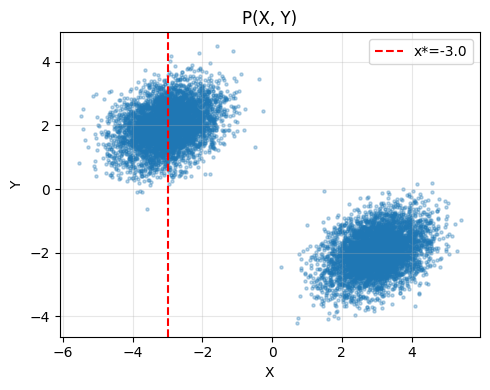

In [16]:
mu_list = [
    torch.tensor([-3.,  2.]),
    torch.tensor([ 3., -2.]),
]
Sigma_list = [
    torch.tensor([[0.5, 0.15],
                  [0.15, 0.4]]),
    torch.tensor([[0.5, 0.15],
                  [0.15, 0.4]]),
]
alpha  = torch.tensor([0.5, 0.5])
x_star = torch.tensor([-3.])

# Target G = P(Y | X = x_star)
mu_temp, Sigma_temp = dist_utils.compute_conditionals(mu_list, Sigma_list, x_star)
w_temp              = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star)
mog_means, mog_variances, weights = dist_utils.filter_and_normalize(
    mu_temp, Sigma_temp, w_temp, threshold=0.001
)
print(f"x_star = {x_star.tolist()}")
print(f"Conditional modes after filtering: {len(mog_means)}")

# Scatter
experiment_utils.set_global_seed(GLOBAL_SEED)
X_data = dist_utils.generate_mog_samples(10_000, mu_list, Sigma_list, alpha).float()
xh = X_data.numpy()
plt.figure(figsize=(5, 4))
plt.scatter(xh[:, 0], xh[:, 1], alpha=0.3, s=5)
plt.axvline(x_star.item(), color='r', ls='--', lw=1.5, label=f"x*={x_star.item()}")
plt.title("P(X, Y)"); plt.xlabel("X"); plt.ylabel("Y")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 3. Simple DDPM

In [17]:

class SimpleNoiseNet(nn.Module):
    """Tiny MLP: predicts noise ε from (x_t, t)."""
    def __init__(self, hidden=128, T=1000):
        super().__init__()
        self.T   = T
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x_t, t):
        B     = x_t.shape[0]
        t_emb = (t.float() / self.T).view(-1, 1).expand(B, 1)
        x_t   = x_t.view(B, 1)
        return self.net(torch.cat([x_t, t_emb], dim=1))


class SimpleDDPM:
    """DDPM for 1D data with linear noise schedule."""
    def __init__(self, T=1000, hidden=128, device="cpu"):
        self.T      = T
        self.device = device

        beta_start, beta_end = 1e-4, 0.02
        self.betas      = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas     = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

        self.model = SimpleNoiseNet(hidden=hidden, T=T).to(device)

    def q_sample(self, x0, t):
        """Forward: x_t = sqrt(ᾱ_t)*x0 + sqrt(1-ᾱ_t)*ε"""
        ab  = self.alpha_bars[t].view(-1, 1)
        eps = torch.randn_like(x0)
        return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, eps

    def tweedie(self, x_t, t):
        """x̂₀ = (x_t - sqrt(1-ᾱ_t)*ε_θ) / sqrt(ᾱ_t) — differentiable."""
        ab  = self.alpha_bars[t]
        eps = self.model(x_t, torch.tensor([t], device=self.device))
        return (x_t - (1 - ab).sqrt() * eps) / ab.sqrt()

    def train(self, data_fn, n_samples=512, nepochs=20_000, lr=1e-3):
        opt = torch.optim.Adam(self.model.parameters(), lr=lr)
        for epoch in range(nepochs):
            x0 = data_fn(n_samples).to(self.device).view(-1, 1)
            t  = torch.randint(0, self.T, (len(x0),), device=self.device)
            x_t, eps = self.q_sample(x0, t)
            loss = ((self.model(x_t, t) - eps) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            if epoch % 2000 == 0:
                print(f"  epoch {epoch:5d} | loss={loss.item():.4f}")


    @torch.no_grad()
    def sample(self, n=1, ddim_steps=50, eta=0.0):
        """DDIM reverse sampling."""
        step_ratio = self.T // ddim_steps
        timesteps  = list(reversed(range(0, self.T, step_ratio)))  # e.g. [999, 979, ...]

        x = torch.randn(n, 1, device=self.device)
        for i, t in enumerate(timesteps):
            t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else -1

            ab      = self.alpha_bars[t]
            ab_prev = self.alpha_bars[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=self.device)

            eps     = self.model(x, torch.tensor([t], device=self.device))
            x0_hat  = (x - (1 - ab).sqrt() * eps) / ab.sqrt()
            x0_hat  = x0_hat.clamp(-10, 10)

            # DDIM step (eta=0 → deterministic)
            sigma   = eta * ((1 - ab_prev) / (1 - ab)).sqrt() * (1 - ab / ab_prev).sqrt()
            x       = ab_prev.sqrt() * x0_hat + \
                      (1 - ab_prev - sigma ** 2).sqrt() * eps + \
                      sigma * torch.randn_like(x)
        return x

    def save(self, path):
        torch.save(self.model.state_dict(), path)
        print(f"Saved → {path}")

    def load(self, path):
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        print(f"Loaded ← {path}")

print("SimpleDDPM defined.")

SimpleDDPM defined.


In [18]:
# ── Conditional Diffusion: train P(Y | X) ────────────────────────────────────
class CondNoiseNet(torch.nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        # input: [y_t, x_cond, t_emb]
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, 1),
        )
    def forward(self, y, x_cond, t):
        t_emb = (t.float() / T).view(-1, 1)
        inp   = torch.cat([y, x_cond, t_emb], dim=-1)
        return self.net(inp)


In [19]:
# ── Consistency Model: train P(Y | X) with iCT ───────────────────────────────
class CondConsistencyNet(torch.nn.Module):
    """F_θ(y_t, x, t) → y_0  (direct denoiser)."""
    def __init__(self, hidden=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(3, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, 1),
        )
    def forward(self, y, x_cond, t):
        t_emb = (t.float() / T).view(-1, 1)
        return self.net(torch.cat([y, x_cond, t_emb], dim=-1))


[Seed] All random seeds set to 42
Training DDPM ...
  epoch     0 | loss=1.0241
  epoch  2000 | loss=0.3740
  epoch  4000 | loss=0.3307
  epoch  6000 | loss=0.3454
  epoch  8000 | loss=0.4046
  epoch 10000 | loss=0.3419
  epoch 12000 | loss=0.3536
  epoch 14000 | loss=0.3433
  epoch 16000 | loss=0.3481
  epoch 18000 | loss=0.3812
Saved → /content/conditional-matching-paper/checkpoints/2D_cond_1D/ddpm_T999_seed42.pt


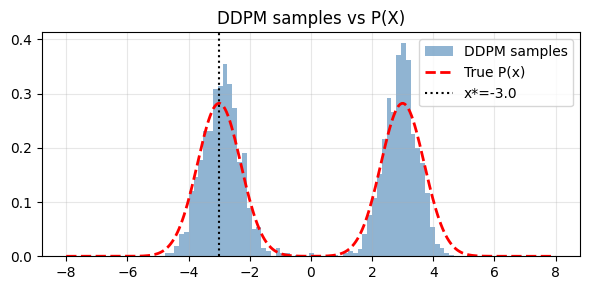

In [20]:
# Data function — samples X marginal from GMM
def sample_px(n):
    return dist_utils.generate_mog_samples_not_differentiable(
        n, mu_list, Sigma_list, alpha,
        kernel_func=lambda X: X[:, :CONDITION_ON]
    ).float()

ddpm = SimpleDDPM(T=T, hidden=HIDDEN, device=device)

ckpt_path = os.path.join(CHECKPOINT_DIR, f"ddpm_T{T}_seed{GLOBAL_SEED}.pt")

if not FORCE_RETRAIN and os.path.exists(ckpt_path):
    ddpm.load(ckpt_path)
else:
    experiment_utils.set_global_seed(GLOBAL_SEED)
    print("Training DDPM ...")
    ddpm.train(sample_px, n_samples=BATCH_SIZE, nepochs=NEPOCHS)
    ddpm.save(ckpt_path)

# Sanity — samples vs true P(X)
torch.set_grad_enabled(True)
with torch.no_grad():
    samps_ddpm = ddpm.sample(2000, ddim_steps=20, eta=1.0).cpu().numpy().flatten()
    # samps_ddpm = ddpm.sample(2000).cpu().numpy().flatten()

x_grid  = np.linspace(-8, 8, 300)
px_true = []
for xv in x_grid:
    xv_t = torch.tensor([float(xv)])
    lps  = [torch.log(w) + torch.distributions.Normal(mu[0], Sigma[0,0].sqrt()).log_prob(xv_t[0])
            for mu, Sigma, w in zip(mu_list, Sigma_list, alpha)]
    px_true.append(torch.logsumexp(torch.stack(lps), 0).exp().item())
px_true = np.array(px_true)

plt.figure(figsize=(6, 3))
plt.hist(samps_ddpm, bins=60, density=True, alpha=0.6,
         color='steelblue', label="DDPM samples")
plt.plot(x_grid, px_true, 'r--', lw=2, label="True P(x)")
plt.axvline(x_star.item(), color='k', ls=':', label=f"x*={x_star.item()}")
plt.title("DDPM samples vs P(X)"); plt.legend()
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 5. L2-GMM Loss Helper

In [21]:
def _ensure_3d_cov(S):
    if S.dim() == 1: return S.view(-1, 1, 1)
    if S.dim() == 2:
        return S.unsqueeze(-1) if S.shape[-1] == 1 else torch.diag_embed(S)
    return S


def gmm_l2_diff(mu_p, Sigma_p, w_p, mu_q, Sigma_q, w_q):
    """Exact differentiable L2^2 distance between two GMMs."""
    if mu_p.dim() == 1: mu_p = mu_p.unsqueeze(0)
    if mu_q.dim() == 1: mu_q = mu_q.unsqueeze(0)
    Sigma_p = _ensure_3d_cov(Sigma_p)
    Sigma_q = _ensure_3d_cov(Sigma_q)
    D = mu_p.shape[-1]

    def inner(m1, S1, w1, m2, S2, w2):
        diff  = m1.unsqueeze(1) - m2.unsqueeze(0)
        S_sum = S1.unsqueeze(1) + S2.unsqueeze(0)
        _, logdet = torch.linalg.slogdet(S_sum)
        quad  = torch.einsum('ijk,ijkl,ijl->ij', diff, torch.linalg.inv(S_sum), diff)
        log_val = -0.5 * (D * math.log(2 * math.pi) + logdet + quad)
        log_w   = torch.log(w1).unsqueeze(1) + torch.log(w2).unsqueeze(0)
        return torch.exp(log_w + log_val).sum()

    pp = inner(mu_p, Sigma_p, w_p, mu_p, Sigma_p, w_p)
    qq = inner(mu_q, Sigma_q, w_q, mu_q, Sigma_q, w_q)
    pq = inner(mu_p, Sigma_p, w_p, mu_q, Sigma_q, w_q)
    return pp - 2 * pq + qq

print("L2-GMM helpers defined.")

L2-GMM helpers defined.


## 6. Analytical Q(x; β) via L2-GMM

Computing P(x) and L(x) on grid ...


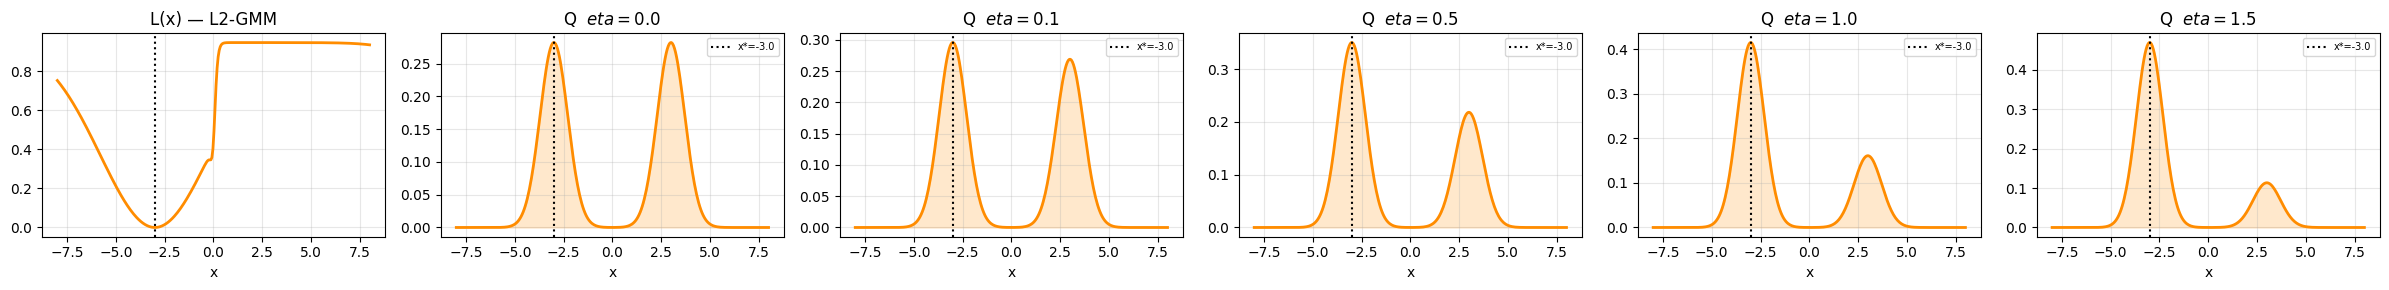

Analytical Q computed.


In [22]:
def marginal_density(x_val):
    xv  = torch.tensor([float(x_val)])
    lps = [torch.log(w) + torch.distributions.Normal(mu[0], Sigma[0,0].sqrt()).log_prob(xv[0])
           for mu, Sigma, w in zip(mu_list, Sigma_list, alpha)]
    return torch.logsumexp(torch.stack(lps), 0).exp().item()


def l2gmm_loss_at_x(x_val):
    xt             = torch.tensor([float(x_val)])
    mu_pred, Sig_p = dist_utils.compute_conditionals(mu_list, Sigma_list, xt)
    w_pred         = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, xt)
    return dist_utils.gmm_l2_distance(mu_pred, Sig_p, w_pred,
                                      mog_means, mog_variances, weights)


print("Computing P(x) and L(x) on grid ...")
px_grid   = np.array([marginal_density(xv) for xv in x_grid])
lx_l2     = np.array([l2gmm_loss_at_x(xv)  for xv in x_grid])

analytical_Q_l2 = {}
for z in ZETA_VALUES:
    q = px_grid * np.exp(-z * lx_l2)
    analytical_Q_l2[z] = q / np.trapezoid(q, x_grid)

# Plot L(x) and Q for each beta
fig, axes = plt.subplots(1, len(ZETA_VALUES) + 1, figsize=(4 * (len(ZETA_VALUES)+1), 3))
axes[0].plot(x_grid, lx_l2, color='darkorange', lw=2)
axes[0].axvline(x_star.item(), color='k', ls=':', lw=1.5)
axes[0].set_title("L(x) — L2-GMM"); axes[0].set_xlabel("x"); axes[0].grid(True, alpha=0.3)

for ax, zeta in zip(axes[1:], ZETA_VALUES):
    ax.plot(x_grid, analytical_Q_l2[zeta], color='darkorange', lw=2)
    ax.fill_between(x_grid, analytical_Q_l2[zeta], alpha=0.2, color='darkorange')
    ax.axvline(x_star.item(), color='k', ls=':', lw=1.5, label=f"x*={x_star.item():.1f}")
    ax.set_title(rf"Q  $eta={zeta}$"); ax.set_xlabel("x")
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

plt.tight_layout(); plt.show()
print("Analytical Q computed.")

## 7. LGD Sampler — Tweedie + L2-GMM

In [23]:
def optimize_LGD_simple_ddpm(ddpm, mu_list, Sigma_list, alpha,
                              mog_means, mog_variances, weights,
                              zeta=1.0, device="cpu",
                              ddim_steps=10, eta=1.0):  # <-- added
    x_t = torch.randn(1, 1, device=device)

    # DDIM schedule — 20 steps instead of T
    step_ratio = ddpm.T // ddim_steps
    timesteps  = list(reversed(range(0, ddpm.T, step_ratio)))  # <-- replaces range(T-1, 0, -1)

    for i, t in enumerate(timesteps):
        t_prev = timesteps[i + 1] if i + 1 < len(timesteps) else -1

        x_t = x_t.detach().clone().requires_grad_(True)

        ab      = ddpm.alpha_bars[t]
        ab_prev = ddpm.alpha_bars[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=device)

        eps     = ddpm.model(x_t, torch.tensor([t], device=device))
        pred_x0 = (x_t - (1 - ab).sqrt() * eps) / ab.sqrt()

        # DDIM reverse step (detached)
        with torch.no_grad():
            sigma       = eta * ((1 - ab_prev) / (1 - ab)).sqrt() * (1 - ab / ab_prev).sqrt()
            x_t_minus_1 = ab_prev.sqrt() * pred_x0.detach() + \
                          (1 - ab_prev - sigma ** 2).sqrt() * eps.detach() + \
                          sigma * torch.randn_like(x_t)

        if zeta == 0.0:
            x_t = x_t_minus_1.detach().clone()
            continue

        # L2-GMM loss — unchanged from here down
        x0_dev = pred_x0.view(-1)[:CONDITION_ON]
        x0_cpu = x0_dev.detach().cpu()

        w_pred        = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x0_cpu)
        _, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x0_cpu)

        Sig_p = _ensure_3d_cov(Sigma_pred.to(device).detach())
        w_p   = w_pred.to(device).detach()
        mu_q  = mog_means.squeeze(1).to(device).detach()
        Sig_q = _ensure_3d_cov(mog_variances.squeeze(1).to(device).detach())
        w_q   = weights.to(device).detach()

        mu_p_list = []
        for k in range(len(mu_list)):
            mu_k    = mu_list[k].to(device)
            Sigma_k = Sigma_list[k].to(device)
            Syx     = Sigma_k[CONDITION_ON:, :CONDITION_ON]
            Sxx     = Sigma_k[:CONDITION_ON, :CONDITION_ON]
            shift   = Syx @ torch.linalg.solve(Sxx, (x0_dev - mu_k[:CONDITION_ON]).unsqueeze(-1))
            mu_p_list.append(mu_k[CONDITION_ON:] + shift.squeeze(-1))

        mu_p     = torch.stack(mu_p_list, dim=0)
        loss_val = zeta*gmm_l2_diff(mu_p, Sig_p, w_p, mu_q, Sig_q, w_q)
        loss_val.backward()

        grad = x_t.grad.clone()
        # grad = grad / (grad.norm() + 1e-8)  # normalize to unit norm
        # grad = torch.clamp(grad, -.25, .25)  # clamp to [-1, 1]


        with torch.no_grad():
            x_t = x_t_minus_1 -  grad

    return x_t.detach().float().view(-1).cpu()[0].item()

In [24]:
print(ddpm)        # should show SimpleDDPM object
print(mu_list)     # should show list of tensors
print(mog_means)   # should show conditional means

[tensor([-3.,  2.]), tensor([ 3., -2.])]
tensor([[[2.]]])


## 8. Sample and Plot

In [25]:
torch.set_grad_enabled(True)

all_samps = {}
for zeta in ZETA_VALUES:
    print(f"\n[β={zeta}] sampling {N_CDMS_SAMPLES} points ...")
    samps = []
    for i in trange(N_CDMS_SAMPLES):
        experiment_utils.set_run_seed(GLOBAL_SEED, i)
        s = optimize_LGD_simple_ddpm(
            ddpm, mu_list, Sigma_list, alpha,
            mog_means, mog_variances, weights,
            zeta=zeta, device=device
        )
        samps.append(s)
    all_samps[zeta] = np.array(samps)
    print(f"  mean={np.mean(all_samps[zeta]):.3f}  std={np.std(all_samps[zeta]):.3f}")



[β=0.0] sampling 200 points ...


100%|██████████| 200/200 [00:02<00:00, 72.92it/s]


  mean=-0.181  std=2.936

[β=0.1] sampling 200 points ...


100%|██████████| 200/200 [00:22<00:00,  8.93it/s]


  mean=-0.251  std=2.946

[β=0.5] sampling 200 points ...


...

  mean=-0.624  std=2.934

[β=1.0] sampling 200 points ...


100%|██████████| 200/200 [00:19<00:00, 10.50it/s]


  mean=-1.015  std=2.848

[β=1.5] sampling 200 points ...


100%|██████████| 200/200 [00:19<00:00, 10.08it/s]

  mean=-1.231  std=2.803


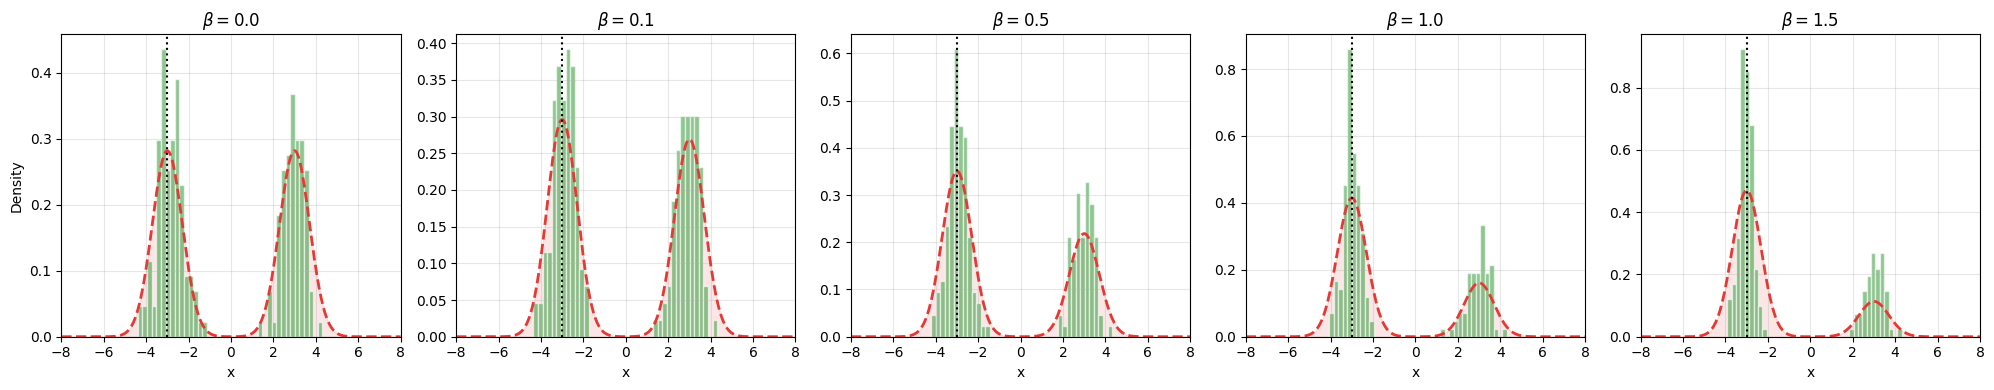

In [26]:
plot_zetas = ZETA_VALUES
fig, axes = plt.subplots(1, len(plot_zetas), figsize=(4 * len(plot_zetas), 4))

for ax, zeta in zip(axes, plot_zetas):
    samps = all_samps[zeta]

    ax.plot(x_grid, analytical_Q_l2[zeta], color="#E53935",
            lw=2, ls='--', label="Analytical Q")
    ax.fill_between(x_grid, analytical_Q_l2[zeta], alpha=0.12, color="#E53935")

    if len(samps) > 1 and np.std(samps) > 1e-6:
        ax.hist(samps, bins=40, density=True, color="#43A047",
                alpha=0.6, edgecolor="white", label=f"DPS (N={len(samps)})")
    else:
        ax.axvline(float(samps[0]), color="#43A047", lw=2, label="Single sample")

    ax.axvline(x_star.item(), color='k', ls=':', lw=1.5,
               label=f"x*={x_star.item():.1f}")
    ax.set_title(rf"$\beta={zeta}$", fontsize=12)
    ax.set_xlabel("x")
    ax.set_ylabel("Density" if ax == axes[0] else "")
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.grid(True, alpha=0.3)

# Single legend taken from the last axis
handles, labels = axes[-1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right", fontsize=9, framealpha=0.5)

# fig.suptitle("Simple DDPM + Tweedie LGD", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# ── Bridge cell ───────────────────────────────────────────────────────────────

def get_gmm_density(y_vals, mu_list_cond, sigma_list_cond, w_list):
    density = torch.zeros(len(y_vals))
    for k in range(len(mu_list_cond)):
        mu_k  = mu_list_cond[k].item() if mu_list_cond[k].numel() == 1 else mu_list_cond[k][0].item()
        sig_k = (sigma_list_cond[k].sqrt().item() if sigma_list_cond[k].numel() == 1
                 else sigma_list_cond[k][0, 0].sqrt().item())
        w_k   = w_list[k].item()
        density += w_k * torch.distributions.Normal(mu_k, sig_k).log_prob(y_vals).exp()
    return density

# Pick best run = lowest L2-GMM
idx_lgd    = 0#int(np.argmin(l2_gmm_LGD_list))
idx_lgd_cm = 0#int(np.argmin(l2_gmm_LGD_CM_list))

best_x_lgd    = best_x_t_LGD_list[idx_lgd].float().view(-1).cpu()[0].item()
best_x_lgd_cm = best_x_t_LGD_CM_list[idx_lgd_cm].float().view(-1).cpu()[0].item()

print(f"best_x_lgd    = {best_x_lgd:.4f}  (L2={l2_gmm_LGD_list[idx_lgd]:.5f})")
print(f"best_x_lgd_cm = {best_x_lgd_cm:.4f}  (L2={l2_gmm_LGD_CM_list[idx_lgd_cm]:.5f})")

best_x_lgd    = -2.9126  (L2=0.00046)
best_x_lgd_cm = -3.1415  (L2=0.00120)


In [28]:
import matplotlib.font_manager as fm
import matplotlib.font_manager as fm

LEGEND_FONTSIZE = 12   # <-- add this line, or reuse whatever value your figure cell uses

plt.rcParams['legend.fontsize'] = LEGEND_FONTSIZE
plt.rcParams['legend.handlelength'] = 1.5
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        for text in leg.get_texts():
            text.set_fontfamily('sans-serif')

<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2996/2257435236.py:83: SyntaxWarning: invalid escape sequence '\m'
  label="Prior $\mathcal{P}(X)$", zorder=1)


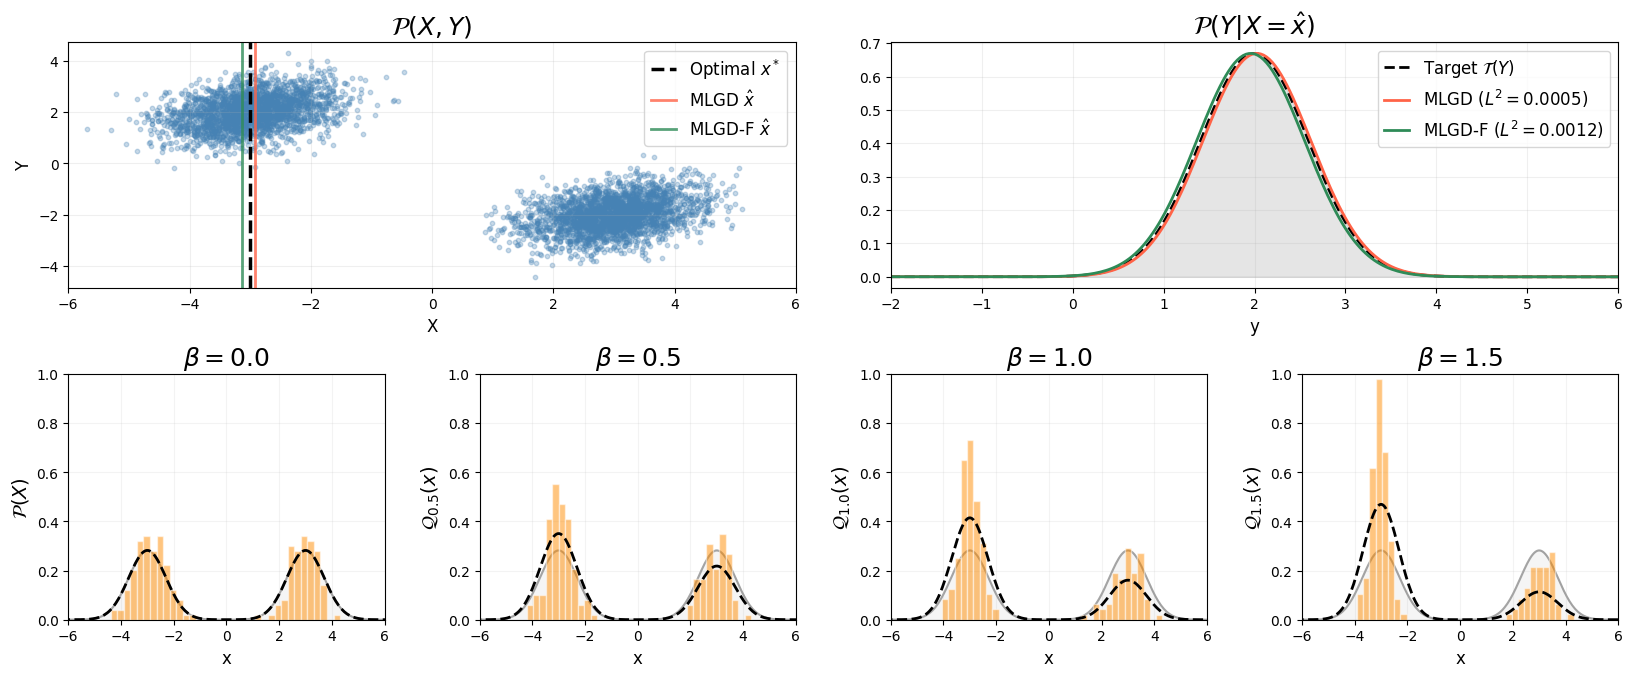

In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
mu_star, sigma_star = dist_utils.compute_conditionals(mu_list, Sigma_list, x_star.cpu())
w_star = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star.cpu())

# --- 1. Setup Figure and Grid ---
# Reduced height from 11 to 7.5 to make it "lower" and paper-friendly
fig = plt.figure(figsize=(20, 7.5))
gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.3, hspace=0.35)

# Styling Constants
main_color = "steelblue"
target_line_color = "black"
optimal_line_color = "BLACK"
lgd_color = "tomato"
lgd_cm_color = "seagreen"
LEGEND_FONTSIZE = 12  # Slightly smaller to fit the lower height

# --- 2. TOP LEFT: Joint Distribution P(X, Y) ---
ax_joint = fig.add_subplot(gs[0, 0:2])
joint_samples = dist_utils.generate_mog_samples_not_differentiable(5000, mu_list, Sigma_list, alpha).cpu().numpy()
ax_joint.scatter(joint_samples[:, 0], joint_samples[:, 1], s=10, alpha=0.3, color=main_color)

ax_joint.axvline(x=x_star.item(), color=optimal_line_color, linestyle="--", lw=2.5, label=fr"Optimal $x^*$")
ax_joint.axvline(x=best_x_lgd, color=lgd_color, alpha=0.8, lw=2, label=fr"MLGD $\hat{{x}}$")
ax_joint.axvline(x=best_x_lgd_cm, color=lgd_cm_color, alpha=0.8, lw=2, label=fr"MLGD-F $\hat{{x}}$")

ax_joint.set_xlim([-6, 6])
ax_joint.set_title(r"$\mathcal{P}(X, Y)$", fontsize=18)
ax_joint.set_xlabel("X", fontsize=12)
ax_joint.set_ylabel("Y", fontsize=12)

handles, labels = ax_joint.get_legend_handles_labels()
ax_joint.legend(handles, labels, fontsize=LEGEND_FONTSIZE, loc='upper right')
ax_joint.grid(alpha=0.2)

# --- 3. TOP RIGHT: Conditional Density P(Y | X=x) ---
ax_target = fig.add_subplot(gs[0, 2:4])
y_range_plot = torch.linspace(-8, 8, 500)

p_target_y = get_gmm_density(y_range_plot, mu_star, sigma_star, w_star)
ax_target.plot(y_range_plot.numpy(), p_target_y.numpy(), color=target_line_color, lw=2, linestyle="--", label=r"Target $\mathcal{T}(Y)$")
ax_target.fill_between(y_range_plot.numpy(), p_target_y.numpy(), alpha=0.1, color=target_line_color)

# LGD
mu_l, sigma_l = dist_utils.compute_conditionals(mu_list, Sigma_list, torch.tensor([best_x_lgd]))
w_l = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, torch.tensor([best_x_lgd]))
p_lgd_y = get_gmm_density(y_range_plot, mu_l, sigma_l, w_l)
l2_val_lgd = l2_gmm_LGD_list[idx_lgd]
ax_target.plot(y_range_plot.numpy(), p_lgd_y.numpy(), color=lgd_color, lw=2,
               label=fr"MLGD ($L^2 = {l2_val_lgd:.4f}$)")

# LGD-CM
mu_lc, sigma_lc = dist_utils.compute_conditionals(mu_list, Sigma_list, torch.tensor([best_x_lgd_cm]))
w_lc = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, torch.tensor([best_x_lgd_cm]))
p_lgd_cm_y = get_gmm_density(y_range_plot, mu_lc, sigma_lc, w_lc)
l2_val_lgd_cm = l2_gmm_LGD_CM_list[idx_lgd_cm]
ax_target.plot(y_range_plot.numpy(), p_lgd_cm_y.numpy(), color=lgd_cm_color, lw=2,
               label=fr"MLGD-F ($L^2 = {l2_val_lgd_cm:.4f}$)")

ax_target.set_xlim([-2, 6])
ax_target.set_title(r"$\mathcal{P}(Y|X=\hat{x})$", fontsize=18)
ax_target.set_xlabel("y", fontsize=12)
ax_target.set_ylabel(r"", fontsize=14)
ax_target.legend(fontsize=LEGEND_FONTSIZE)
ax_target.grid(alpha=0.2)

# --- 4. BOTTOM ROW: Beta Sweep Plots ---
beta_layout = [0.0, 0.5, 1.0, 1.5]

prior_color   = "gray"
achieved_color = "darkorange"   # samples/achieved dist — orange-ish, drawn below
target_color  = "black"         # target Q_beta — black dashed, drawn on top

for i, z in enumerate(beta_layout):
    ax = fig.add_subplot(gs[1, i])
    samps = all_samps[z]

    # Prior P(X) — shown in every panel so the eye tracks the move from prior to Q_beta
    ax.plot(x_grid, px_grid, color=prior_color, lw=1.5, ls="-", alpha=0.7,
            label="Prior $\mathcal{P}(X)$", zorder=1)
    ax.fill_between(x_grid, px_grid, alpha=0.08, color=prior_color, zorder=1)

    # Achieved distribution (samples) — orange-ish, drawn below the target
    ax.hist(samps, bins=35, density=True, color=achieved_color, alpha=0.5,
            edgecolor="white", label="MLGD Samples", zorder=2)

    # Target Q_beta — black dashed, drawn on top (highest zorder)
    ax.plot(x_grid, analytical_Q_l2[z], color=target_color, lw=2, ls="--",
            label="Analytic $Q$", zorder=3)

    ax.set_ylim([0, 1])          # cut y-axis at 1
    ax.set_xlim([-6, 6])
    ax.set_title(fr"$\beta={z}$", fontsize=18)
    ax.set_xlabel("x", fontsize=12)

    if i == 0:
        ax.set_ylabel(r"$\mathcal{P}(X)$", fontsize=14)
    else:
        ax.set_ylabel(fr"$\mathcal{{Q}}_{{{z}}}(x)$", fontsize=14)

    ax.grid(alpha=0.15)